# Esame - 12 giugno 2024

In [310]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm

## Esercizio 1

**1.**

**4.**

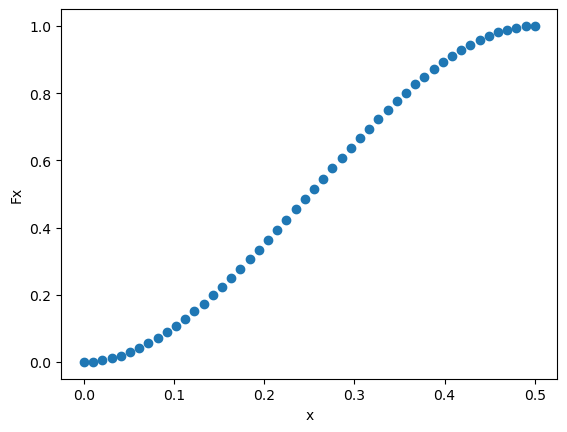

In [311]:
a = 0.5
x = np.linspace(0, a)
Fx = 3*x**2/(a**2) - 2*x**3/(a**3)
plt.plot(x, Fx, 'o')
plt.xlabel('x')
plt.ylabel('Fx')
plt.show()

**5.** Il grafico potrebbe ricordare una distribuzione normale.

In [312]:
Fx = 3*x**2/(a**2) - 2*x**3/(a**3)

## Esercizio 3

In [313]:
ris = pd.read_csv('./Esami completi/risultati.csv', sep=',')
ris.head()

,matricola,genere,eta,punteggio,tempo
0,4302229,F,20,20.49,24.0
1,3199114,F,21,8.53,9.0
2,8399478,F,31,5.28,9.0
3,2658176,F,35,17.37,21.0
4,1492818,M,35,23.34,22.0


In [314]:
# 1
index = ris.columns
pd.DataFrame([ris.matricola.isnull().sum(),
              ris.genere.isnull().sum(),
              ris.eta.isnull().sum(),
              ris.punteggio.isnull().sum(),
              ris.tempo.isnull().sum()], 
             index, 
             columns=[''])


,
matricola,0
genere,0
eta,0
punteggio,0
tempo,0


In [315]:
# 2
ris.genere.describe # si tratta di un tipo categorico

<bound method NDFrame.describe of 0      F
1      F
2      F
3      F
4      M
      ..
663    M
664    F
665    M
666    M
667    M
Name: genere, Length: 668, dtype: object>

In [316]:
pd.crosstab(ris.genere, columns='Frequenza assoluta', colnames=[''])

,Frequenza assoluta
genere,
F,360
M,308


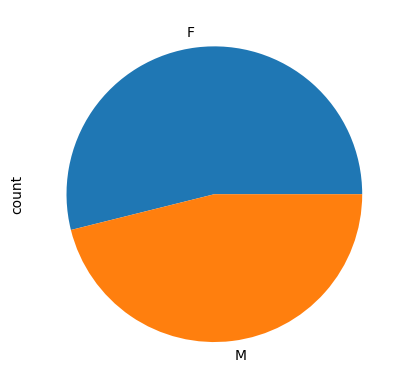

In [317]:
ris.genere.value_counts().plot.pie()
plt.show()

In [318]:
# 3
ris.punteggio.describe # si tratta di tipo scalare

<bound method NDFrame.describe of 0      20.49
1       8.53
2       5.28
3      17.37
4      23.34
       ...  
663    18.99
664    16.83
665    13.62
666    10.88
667    21.47
Name: punteggio, Length: 668, dtype: float64>

In [319]:
bins = range(0,45,5)
pd.crosstab(pd.cut(ris.punteggio, bins, right=False), columns='Frequenza assoluta', colnames=[''])

,Frequenza assoluta
punteggio,
"[0, 5)",47
"[5, 10)",81
"[10, 15)",119
"[15, 20)",140
"[20, 25)",130
"[25, 30)",98
"[30, 35)",51
"[35, 40)",2


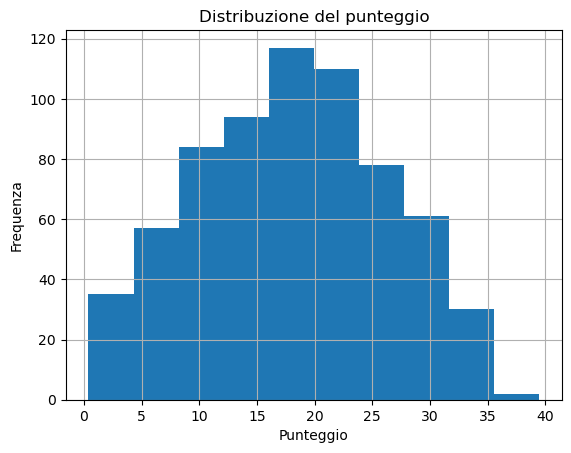

In [320]:
#punteggio.plot.bar()

plt.hist(ris.punteggio)
plt.title('Distribuzione del punteggio')
plt.xlabel('Punteggio')
plt.ylabel('Frequenza')
plt.grid()

plt.show()

In [321]:
# 4 
ris.punteggio.corr(ris.tempo)

0.8134245358444541

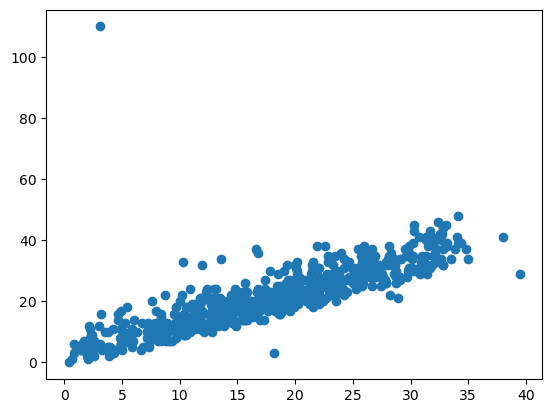

In [322]:
plt.scatter(ris.punteggio, ris.tempo)

Essendo il coefficiente di correlazione vicino ad 1, possiamo affermare che tra gli attributi *punteggio* e *tempo* ci sia una correlazione diretta.
Utilizzare il coefficiente di correlazione mi consente di stabilire la forza e la direzione della correlazione tra due attributi.

In [327]:
# 5
a = ris.punteggio.mean() * 2
a

35.92464071856288

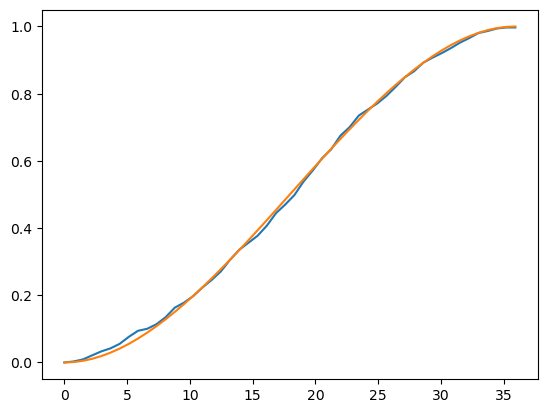

In [334]:
ecdf = sm.distributions.empirical_distribution.ECDF(ris.punteggio)
x = np.linspace(0, a)

plt.plot(x, ecdf(x))
plt.plot(x, Fx)
plt.show()

## Esercizio 4

In [15]:
import pandas as pd
ris = pd.read_csv('risultati.csv')
punteggio = ris.punteggio

FileNotFoundError: [Errno 2] No such file or directory: 'risultati.csv'

In [1]:
# 1
# E[T] = a = E[2*X_campionaria]
a = 2 * punteggio.mean()
a

NameError: name 'punteggio' is not defined

In [ ]:
# 2
# P(|T-\mu| ≤ 1 ) = 2\Phi((\sqrt(5n))/a)-1
Z = st.norm()
n = len(punteggio)
2*Z.cdf((5*n)**(1/2)/a)-1

In [ ]:
# 3
len(punteggio[[p > 21 for p in punteggio]])

In [ ]:
# P(X > 21) = 1 - P(X < 21) = 1 - F(21) 
x = 21
1 - ((3*(x**2)/(a**2))-((2*(x**3))/(a**3)))

In [ ]:
# Infatti, confrontando la probabilità trovata con quella effettiva
# notiamo che, è pressapoco la stessa:
p = 254/len(punteggio)

**4.** $Y$ è una variabile aleatoria binomiale su $3$ prove.
$$
Y \sim B\Big(3, p\Big)
$$

In [ ]:
Y = st.binom(3, p)
print('P(Y=3) =', Y.pmf(3))
print('P(Y=1) =', Y.pmf(1))
print('P(Y≤1) =', Y.cdf(1))

**5.** Z segue il modello geometrico
$$
Z \sim G(p)
$$

In [ ]:
Z = st.geom(p)
print('P(Z=3) =', Z.pmf(3))
print('P(Z≥4|Z≥2) = P(Z≥2) = 1-P(Z≤2) =',1-Z.cdf(2) ) # assenza di memoria